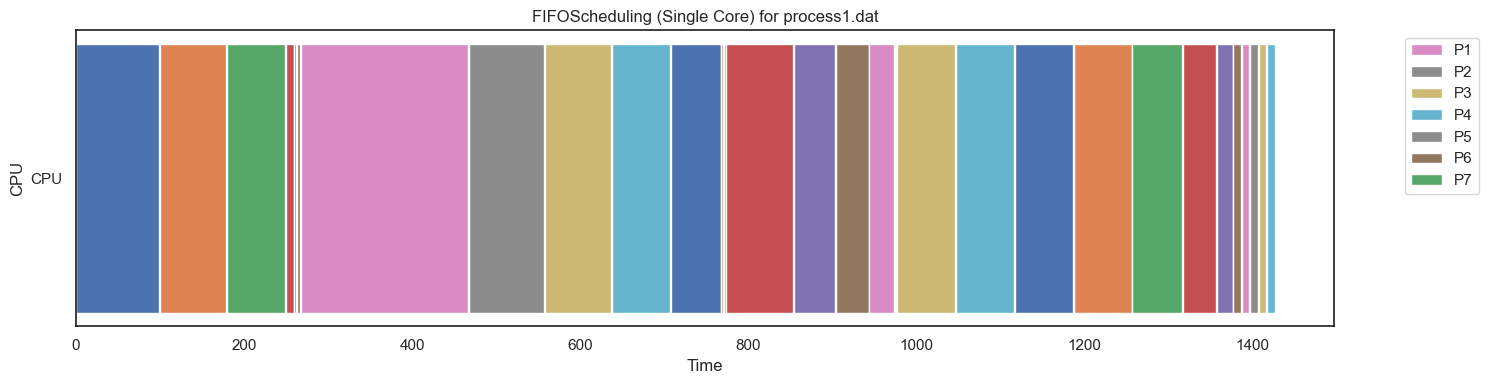

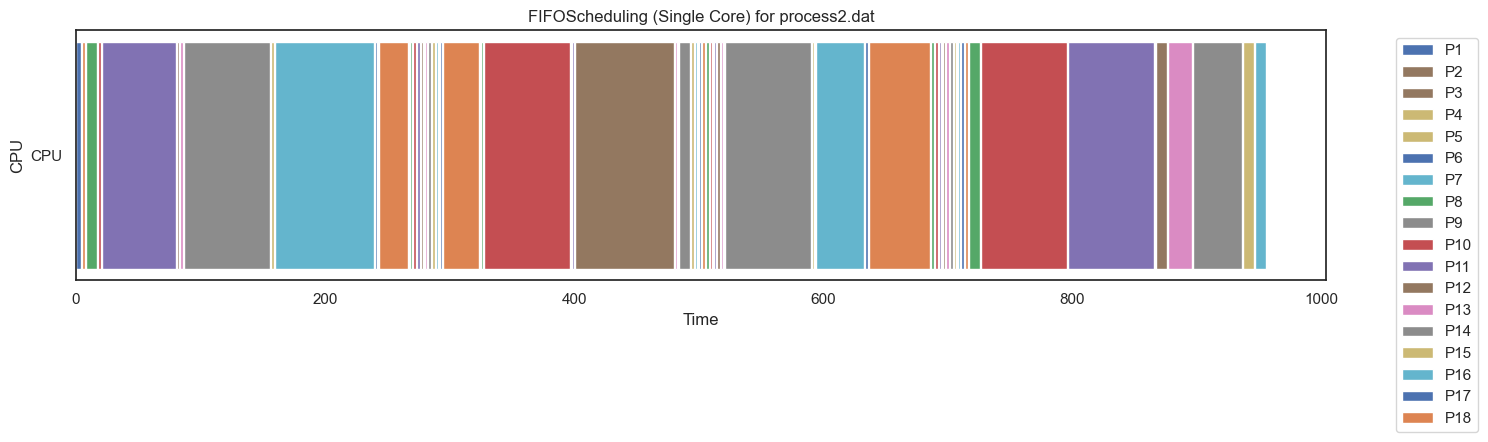

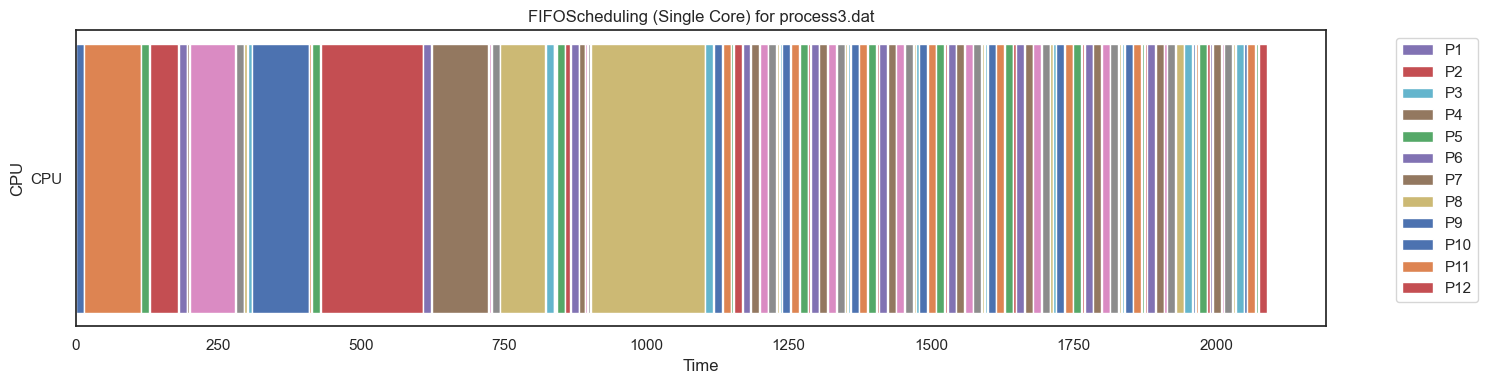

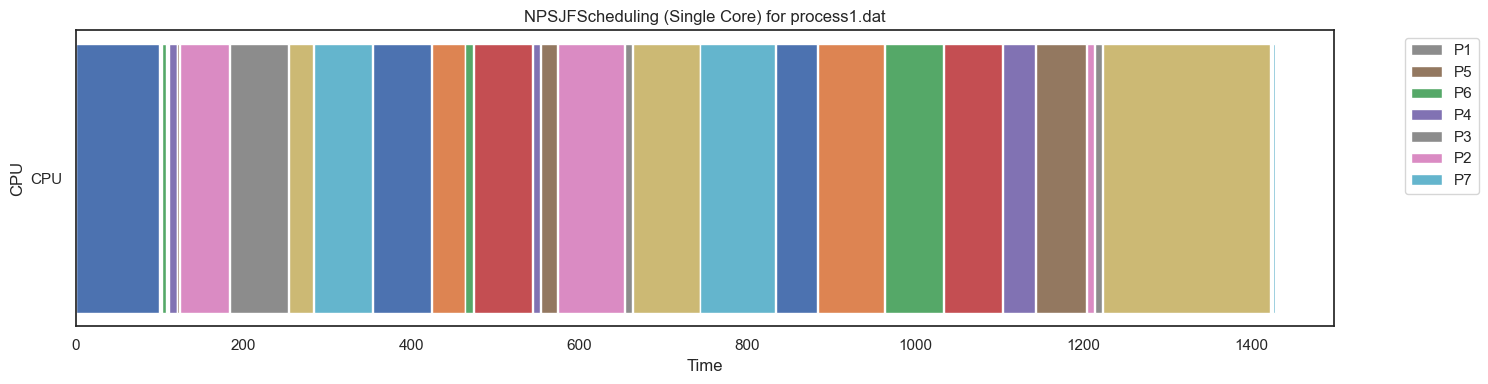

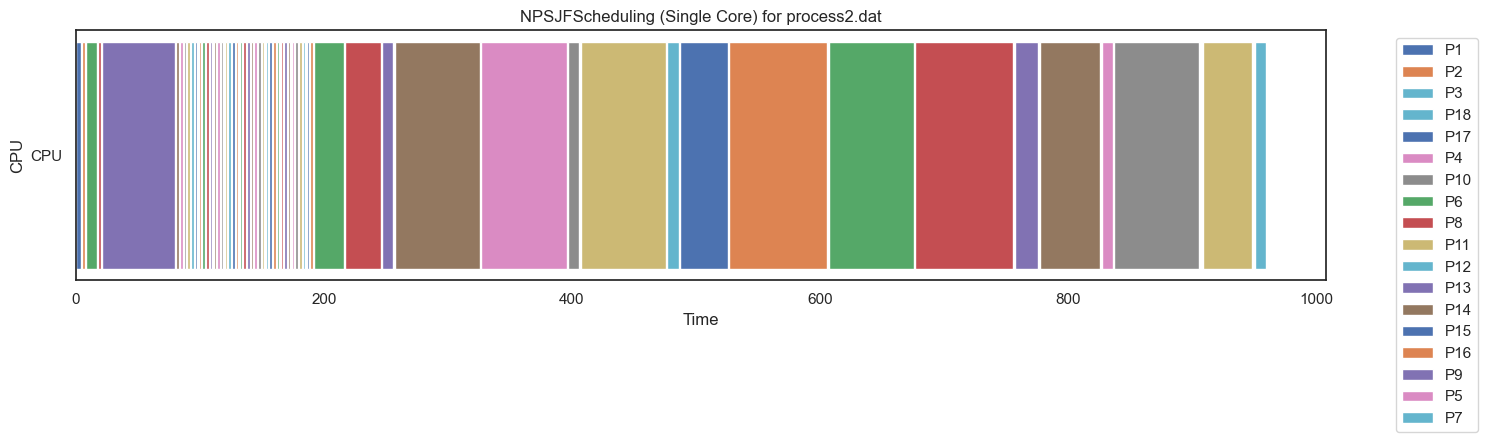

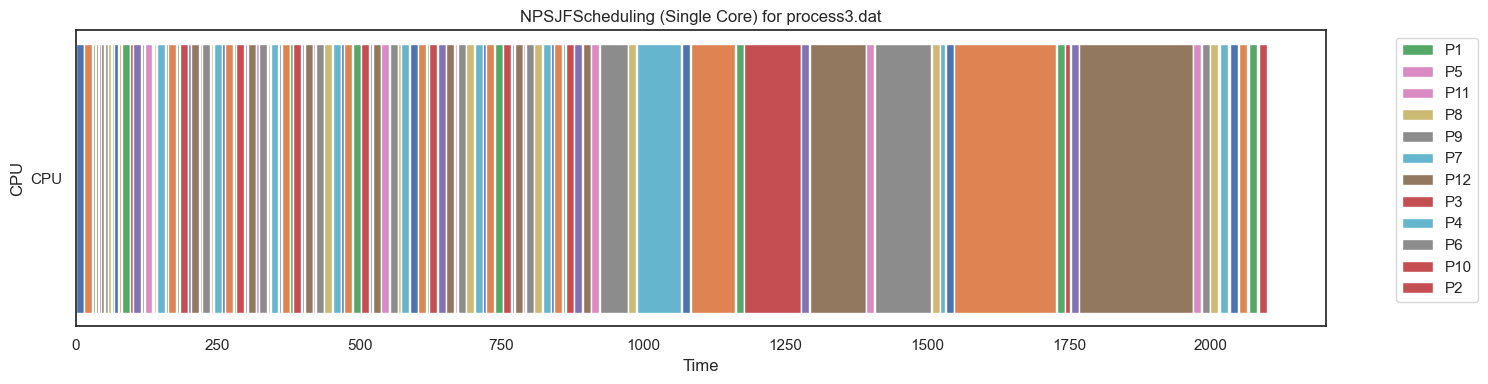

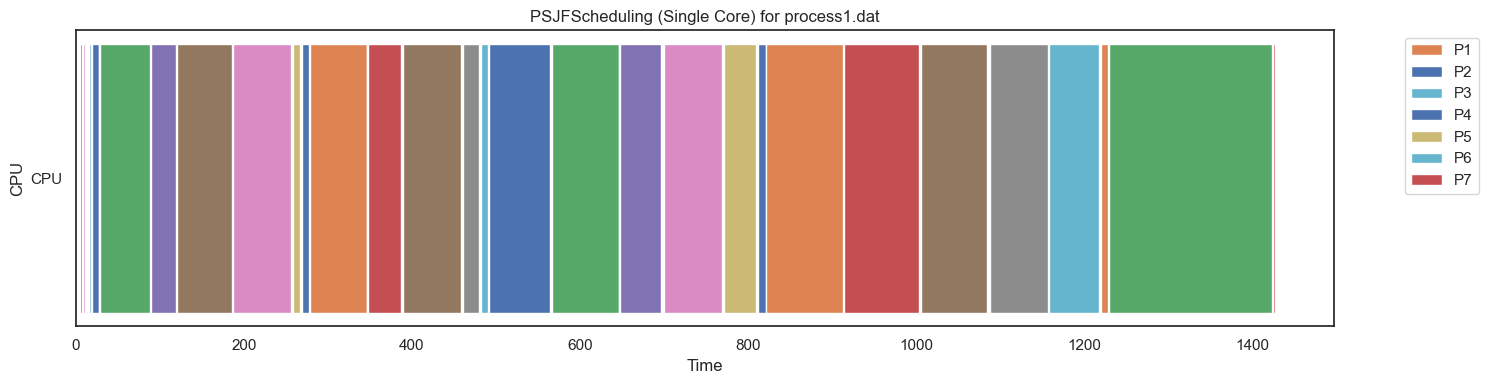

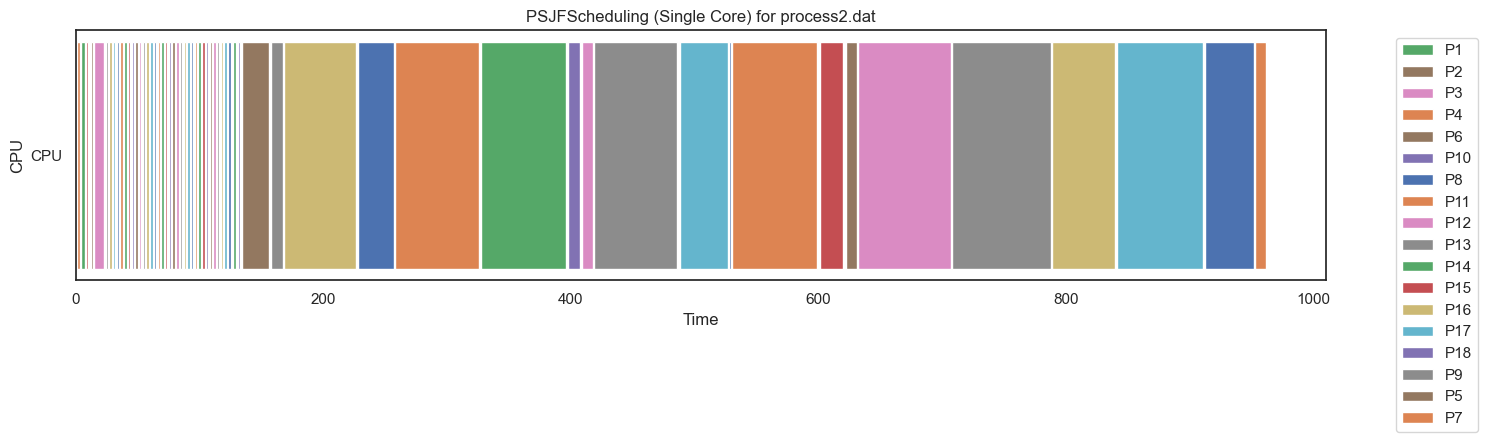

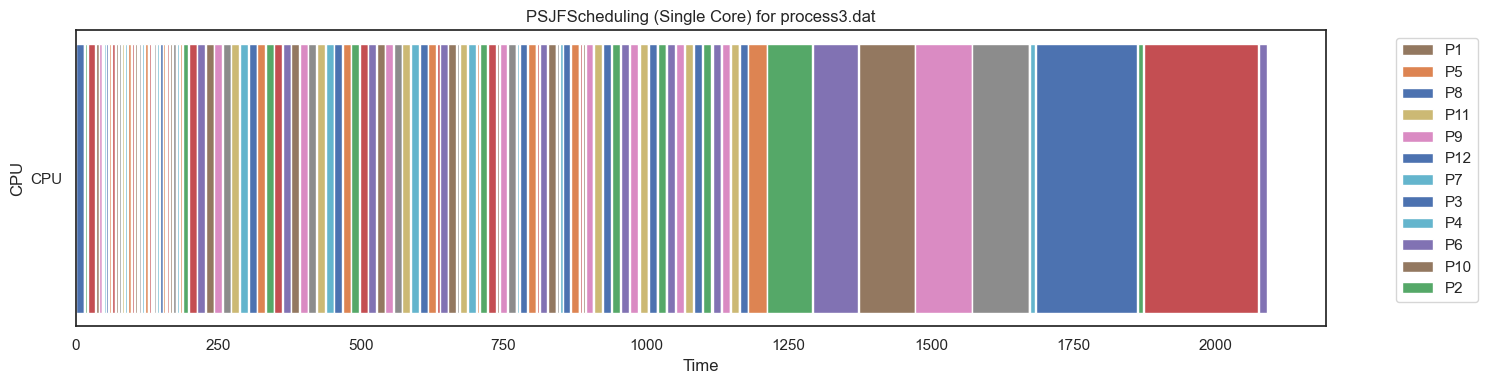

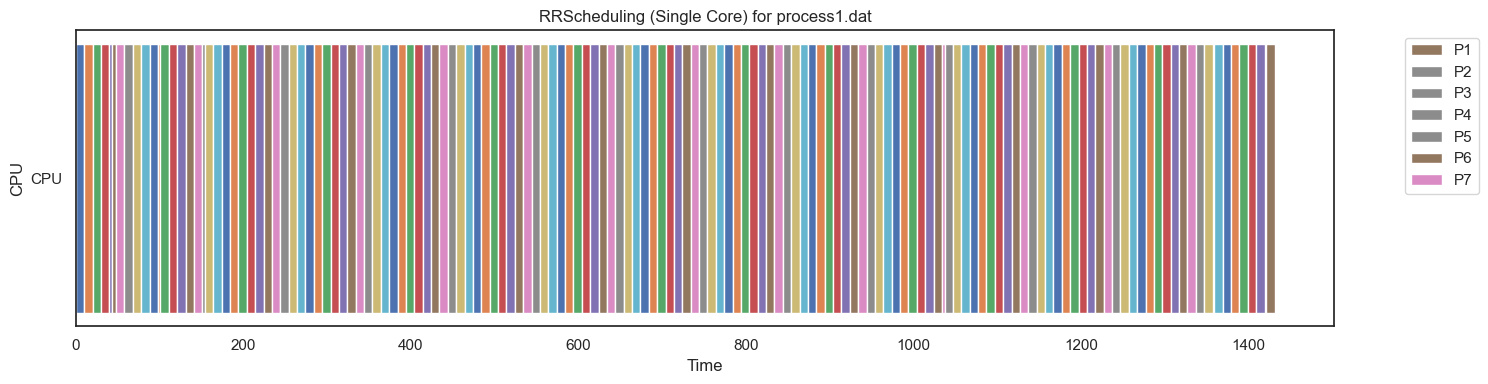

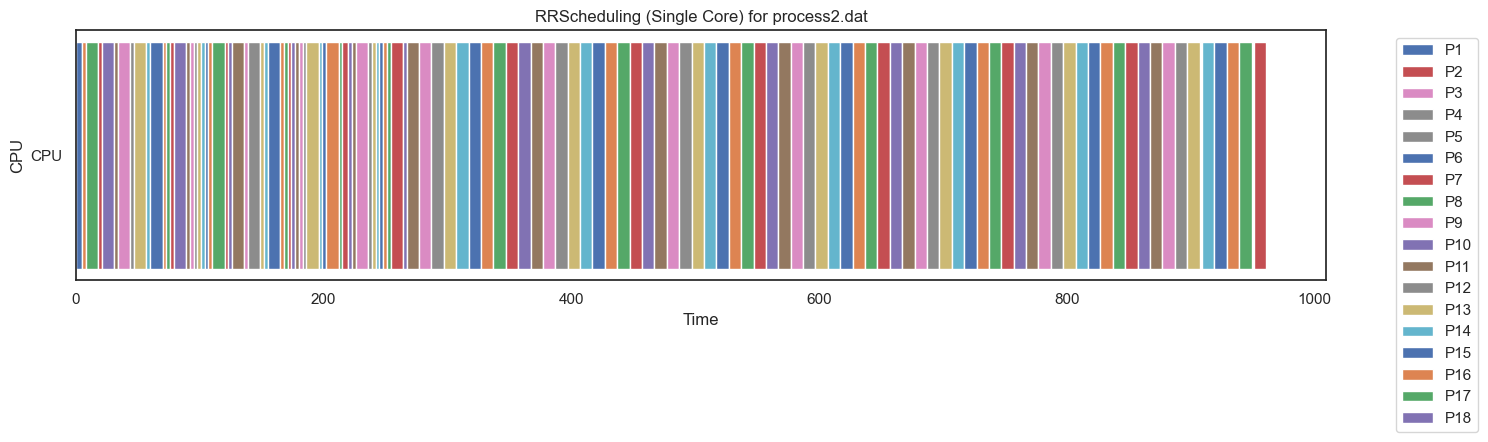

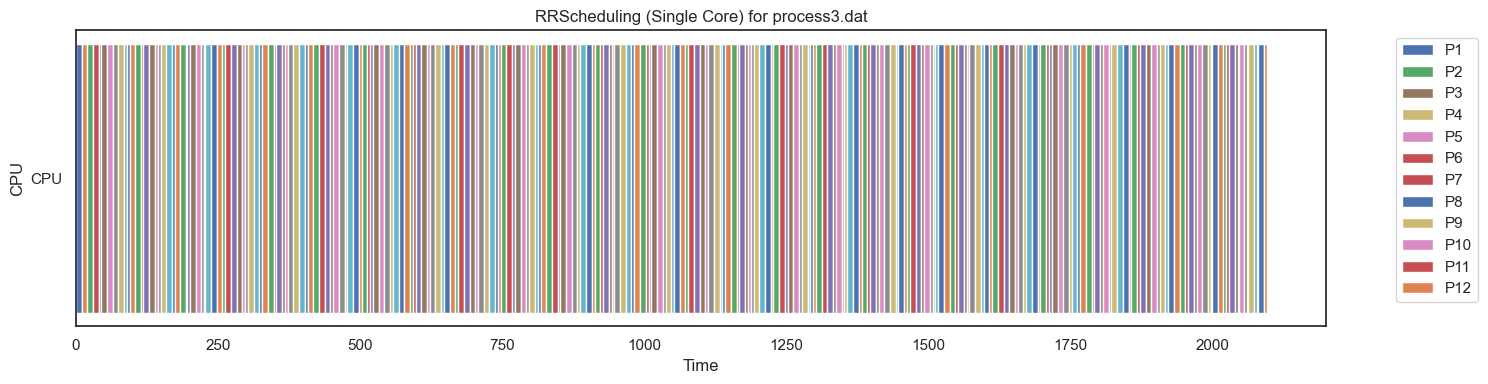

In [37]:
import matplotlib.pyplot as plt

alg0=["FIFO","NPSJF","PSJF","RR"]
for alg in alg0:
    for n in range(1,4):
        rows = []
        n=str(n)
        with open("Schedule("+alg+")"+n+".txt") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 3:
                    proc_slice, start, end = parts
                    proc, slice_num = proc_slice.split(",")
                    rows.append((proc, int(slice_num), int(start), int(end)))
        
        # Plot Gantt Chart (single CPU timeline)
        fig, ax = plt.subplots(figsize=(15, 4))
        
        for proc, slice_num, start, end in rows:
            ax.barh("CPU", end - start, left=start, label=proc)
        
        ax.set_xlabel("Time")
        ax.set_ylabel("CPU")
        ax.set_title(alg+"Scheduling (Single Core) for process"+n+".dat")
        ax.set_yticks(["CPU"])
        
        # Avoid duplicate legend entries
        handles, labels = ax.get_legend_handles_labels()
        unique = dict(zip(labels, handles))
        ax.legend(unique.values(), unique.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.savefig(f"Gantt_{alg}_process{n}.png", dpi=300, bbox_inches='tight')
        plt.tight_layout()
        plt.show()


In [17]:
alg0=["FIFO","NPSJF","PSJF","RR"]
process1_toc = [1427, 1429, 1428, 1431]
process1_max_tat = [1423, 1419, 1417, 1431]
process1_avg_tat = [1091, 755.286, 607, 884]
process1_idle0 = [0, 2, 0, 2]

process2_toc = [957, 961, 963, 961]
process2_max_tat = [931, 935, 936, 935]
process2_avg_tat = [618.444, 216.167, 152.278, 289.778]
process2_idle0 = [0, 4, 0, 2]

process3_toc = [2089, 2091, 2090, 2096]
process3_max_tat = [2062, 2071, 2069, 2056]
process3_avg_tat = [1249.25, 975.833, 898.917, 1267]
process3_idle0 = [0, 2, 0, 3]

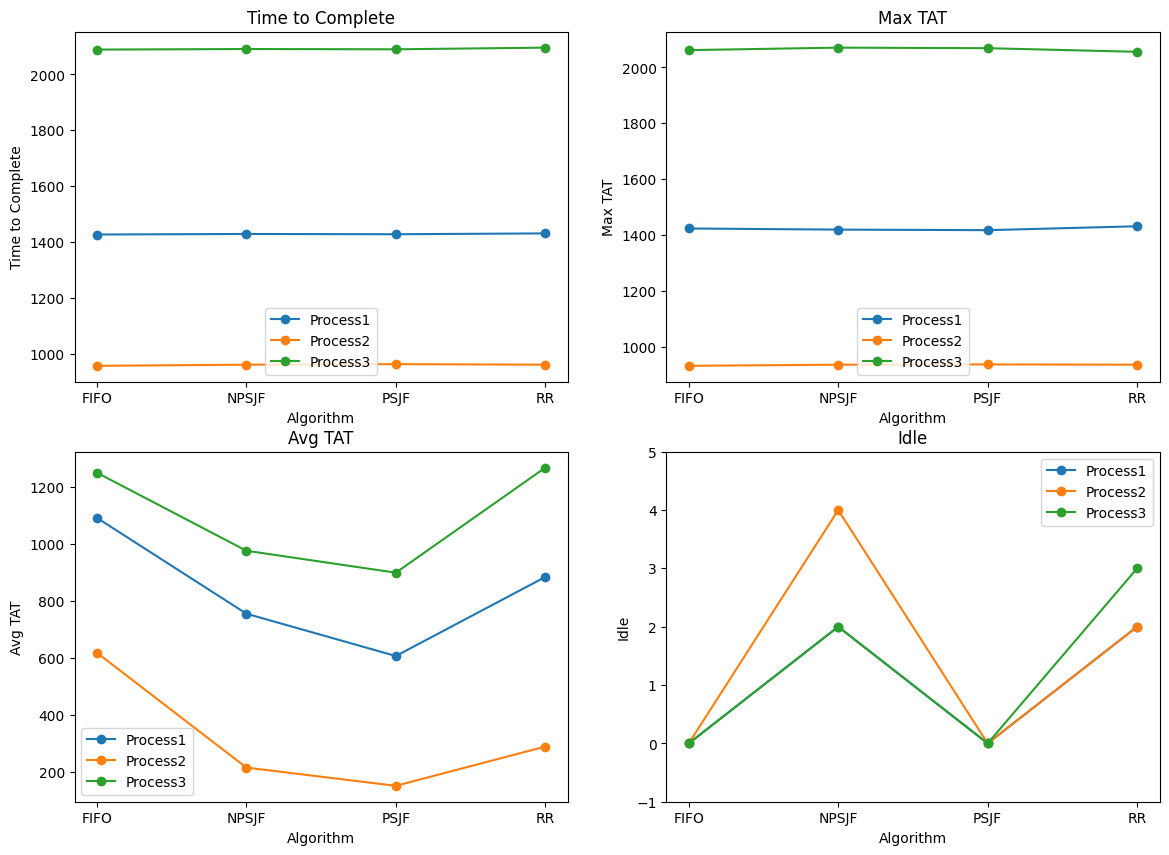

In [19]:
import matplotlib.pyplot as plt

# Algorithms
alg0 = ["FIFO","NPSJF","PSJF","RR"]

# Data
process1_toc = [1427, 1429, 1428, 1431]
process1_max_tat = [1423, 1419, 1417, 1431]
process1_avg_tat = [1091, 755.286, 607, 884]
process1_idle0 = [0, 2, 0, 2]

process2_toc = [957, 961, 963, 961]
process2_max_tat = [931, 935, 936, 935]
process2_avg_tat = [618.444, 216.167, 152.278, 289.778]
process2_idle0 = [0, 4, 0, 2]

process3_toc = [2089, 2091, 2090, 2096]
process3_max_tat = [2062, 2071, 2069, 2056]
process3_avg_tat = [1249.25, 975.833, 898.917, 1267]
process3_idle0 = [0, 2, 0, 3]

# Bundle data
datasets = {
    "Process1": (process1_toc, process1_max_tat, process1_avg_tat, process1_idle0),
    "Process2": (process2_toc, process2_max_tat, process2_avg_tat, process2_idle0),
    "Process3": (process3_toc, process3_max_tat, process3_avg_tat, process3_idle0),
}

metrics = ["Time to Complete", "Max TAT", "Avg TAT", "Idle"]

# Create 4 line plots
plt.figure(figsize=(14, 10))

for i, metric in enumerate(metrics):
    plt.subplot(2, 2, i+1)

    for pname, pdata in datasets.items():
        plt.plot(alg0, pdata[i], marker='o', label=pname)

    plt.title(metric)
    plt.xlabel("Algorithm")
    plt.ylabel(metric)
    plt.legend()

    # Zoom y-axis only for Idle
    if metric == "Idle":
        plt.ylim(-1, max(max(pdata[i] for pdata in datasets.values())) + 1)



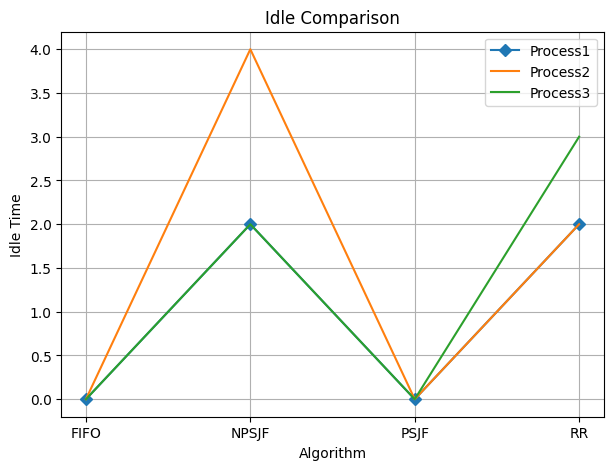

In [23]:
import matplotlib.pyplot as plt

# Algorithms
alg0 = ["FIFO","NPSJF","PSJF","RR"]

# Idle data
process1_idle0 = [0, 2, 0, 2]
process2_idle0 = [0, 4, 0, 2]
process3_idle0 = [0, 2, 0, 3]

plt.figure(figsize=(7,5))

plt.plot(alg0, process1_idle0, marker='D', label="Process1")
plt.plot(alg0, process2_idle0, label="Process2")
plt.plot(alg0, process3_idle0, label="Process3")

plt.title("Idle Comparison")
plt.xlabel("Algorithm")
plt.ylabel("Idle Time")
plt.legend()
plt.grid(True)
plt.show()


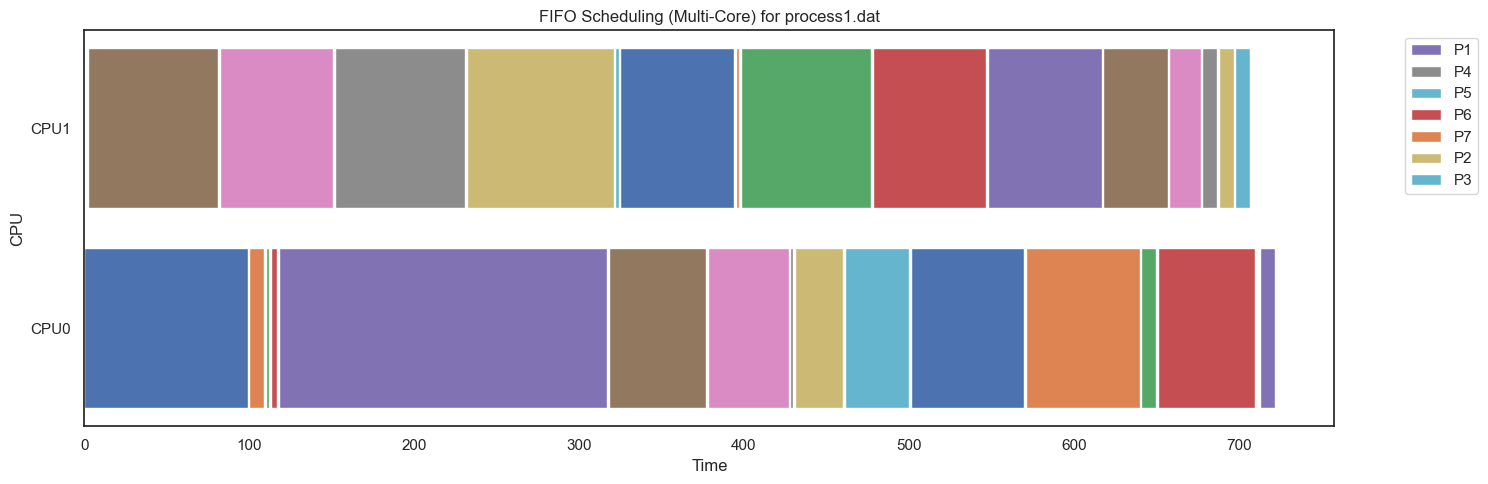

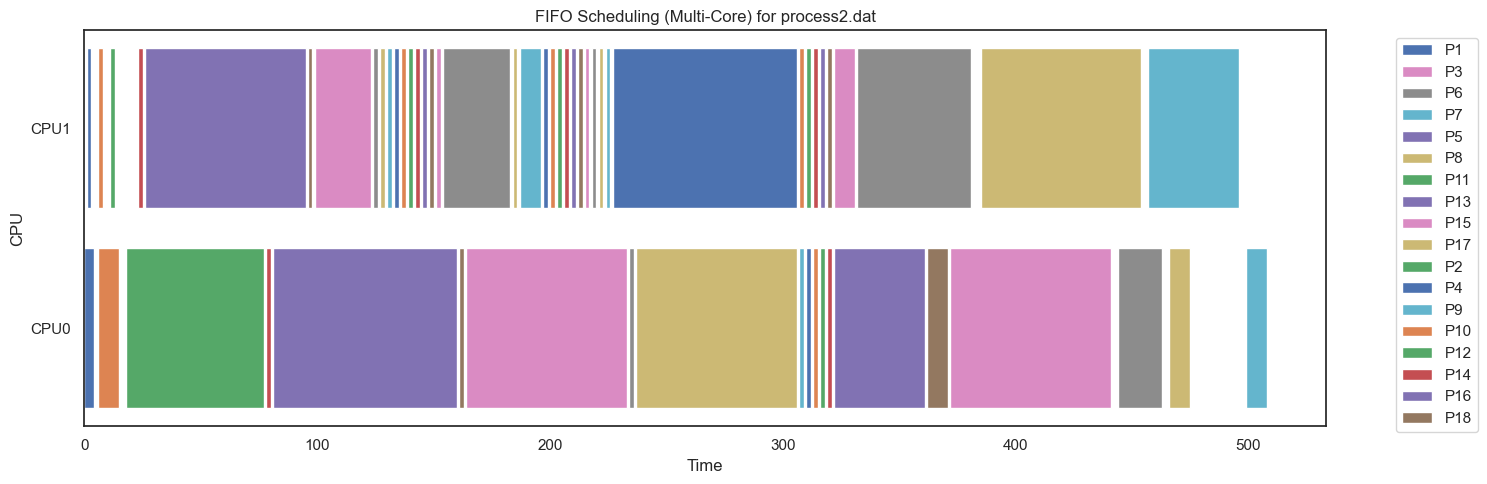

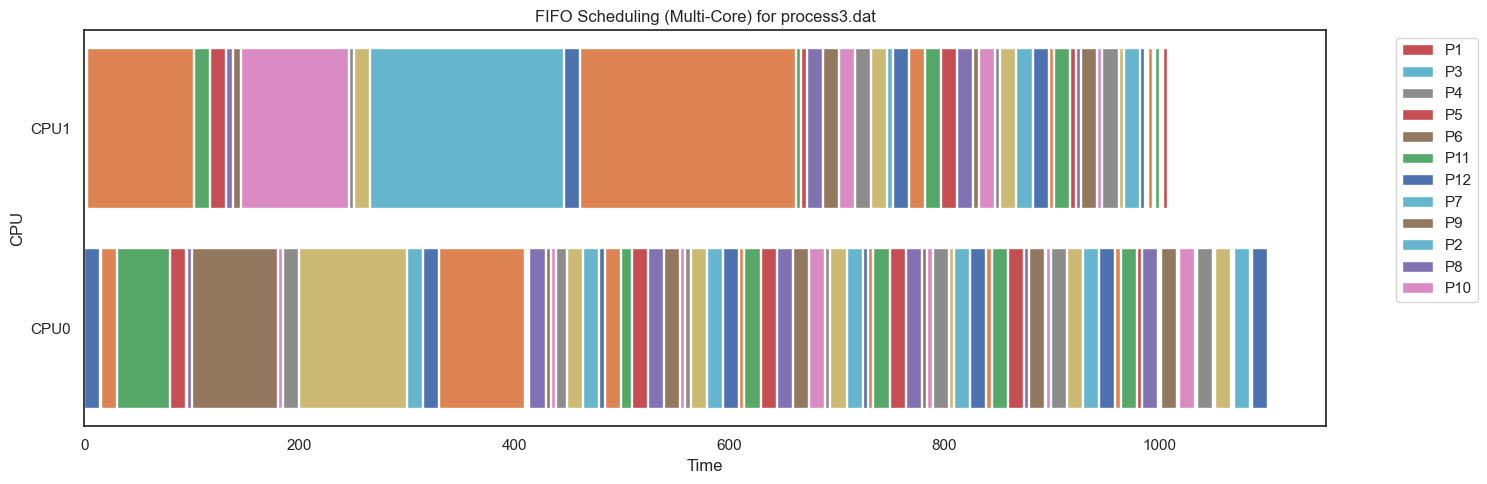

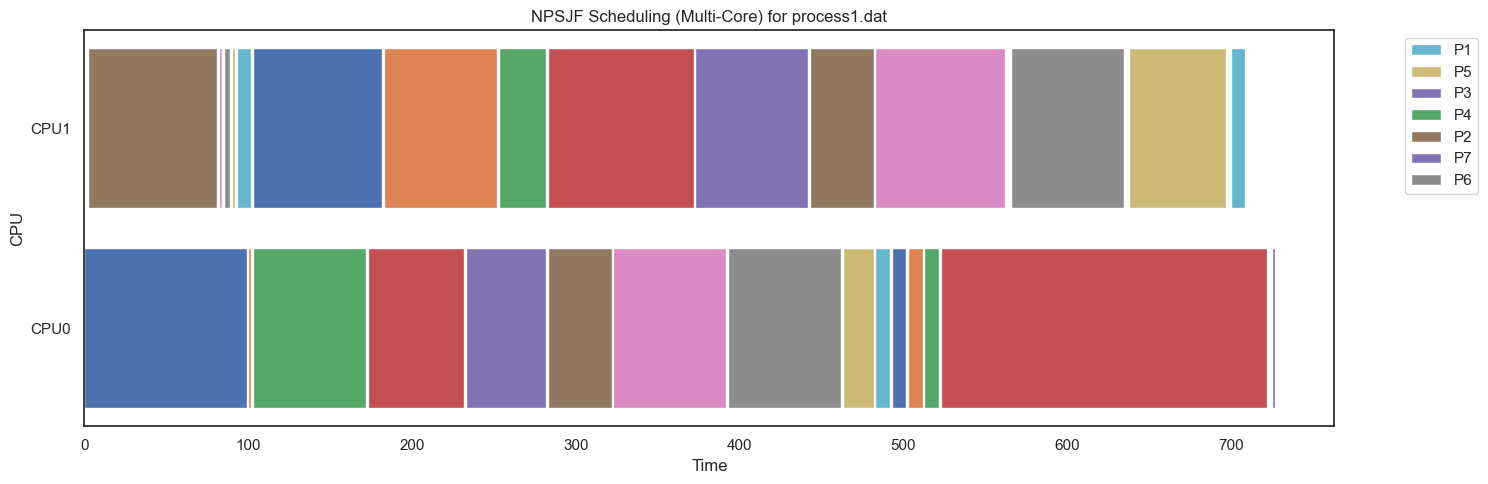

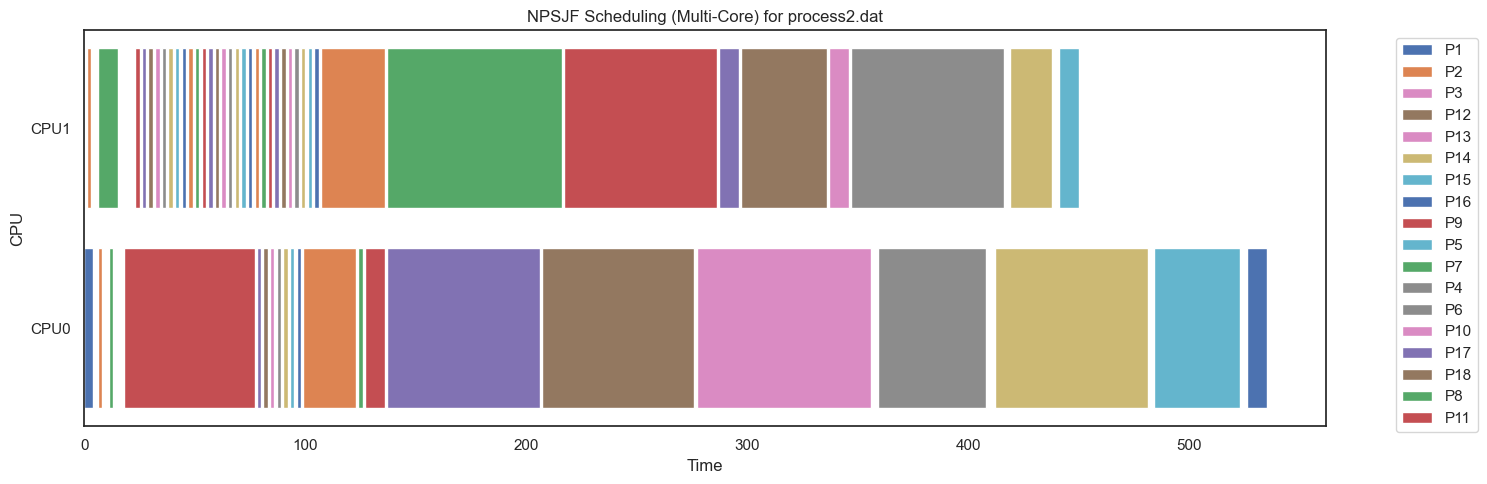

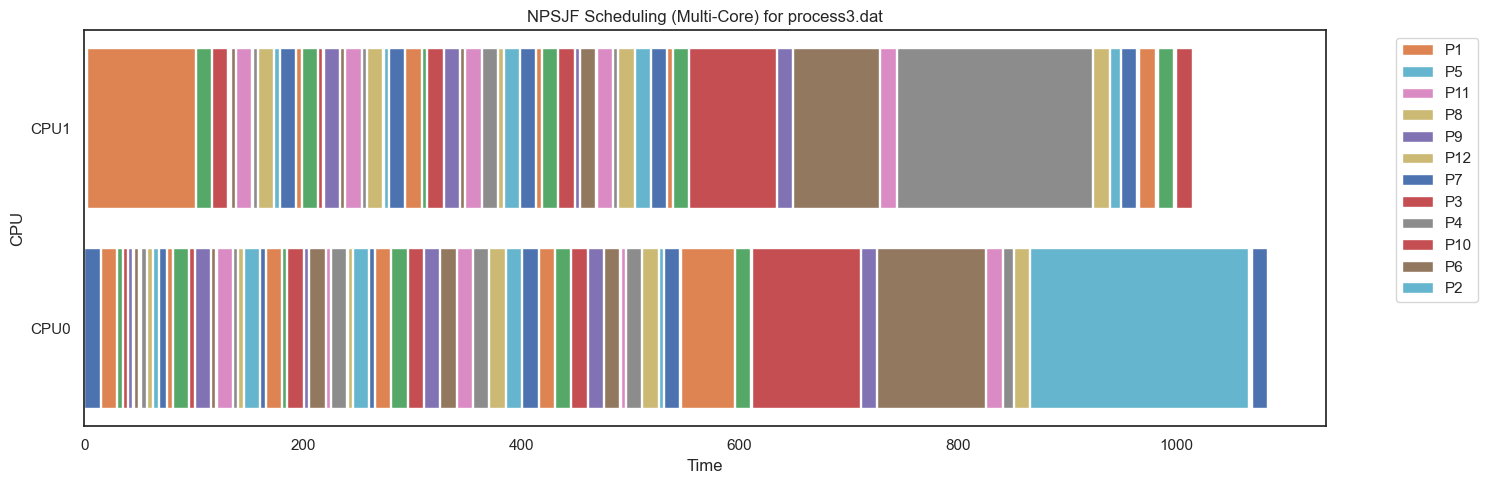

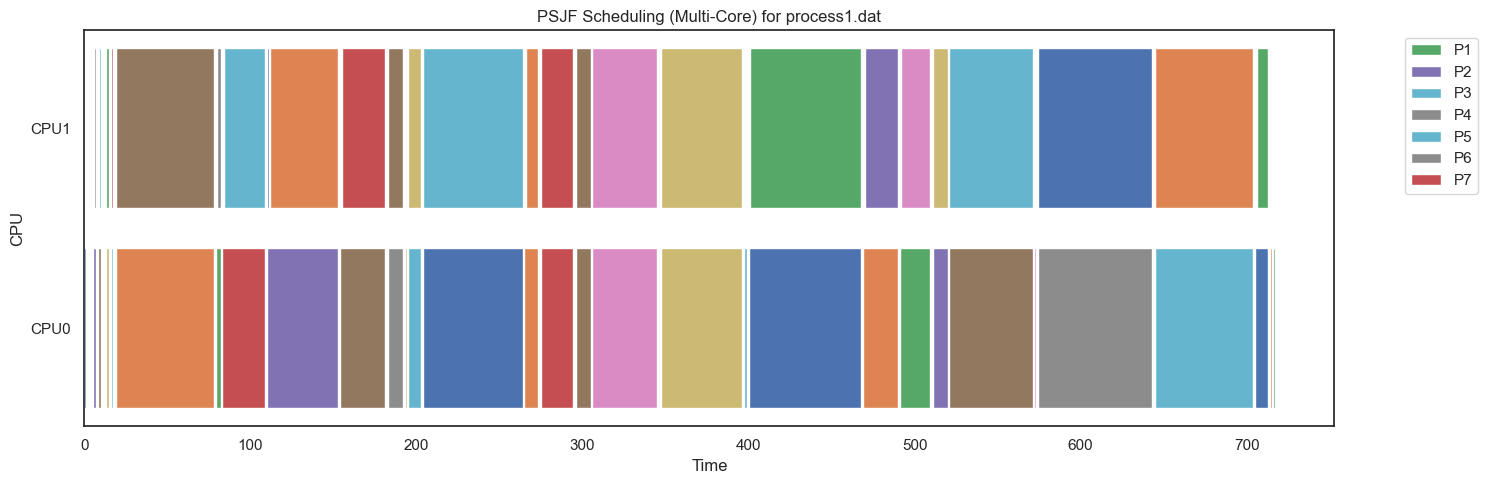

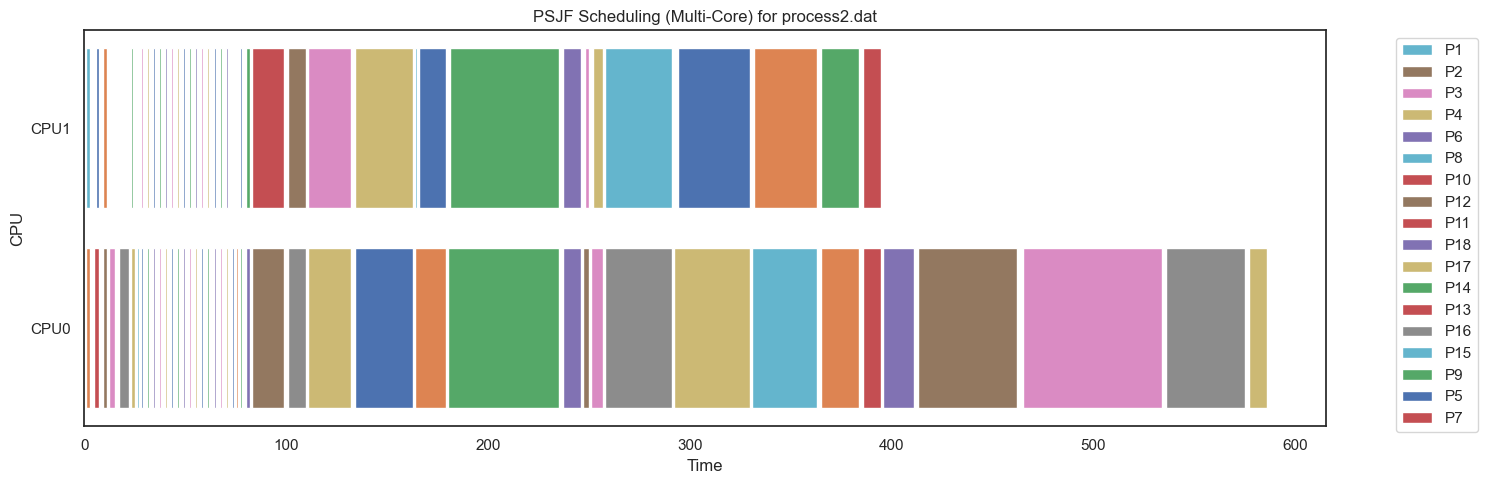

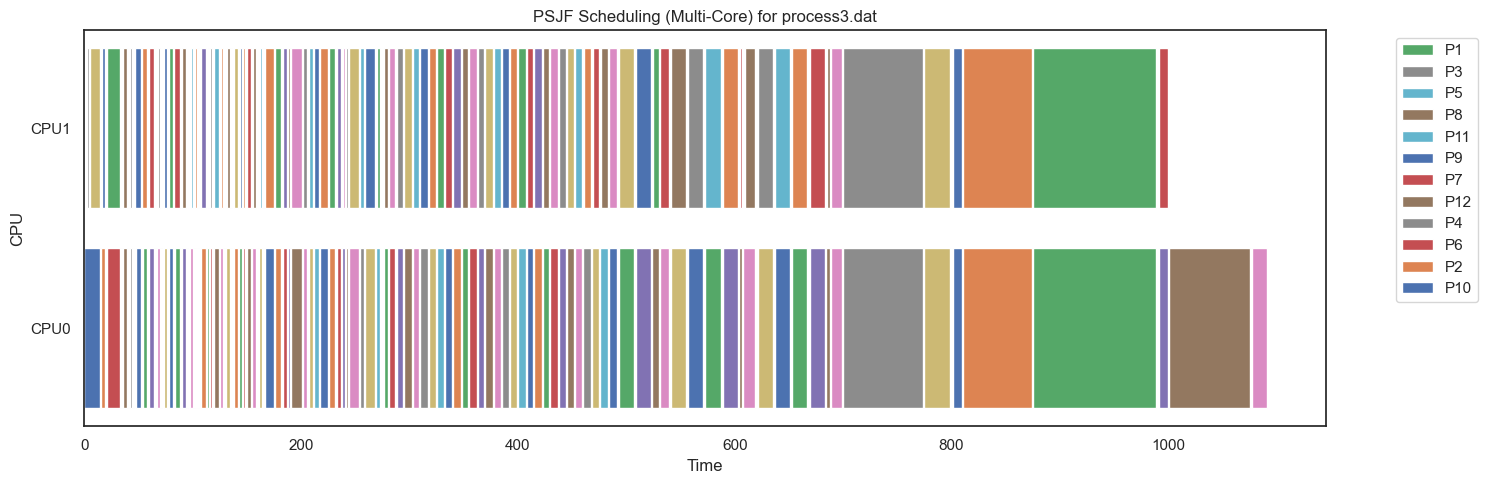

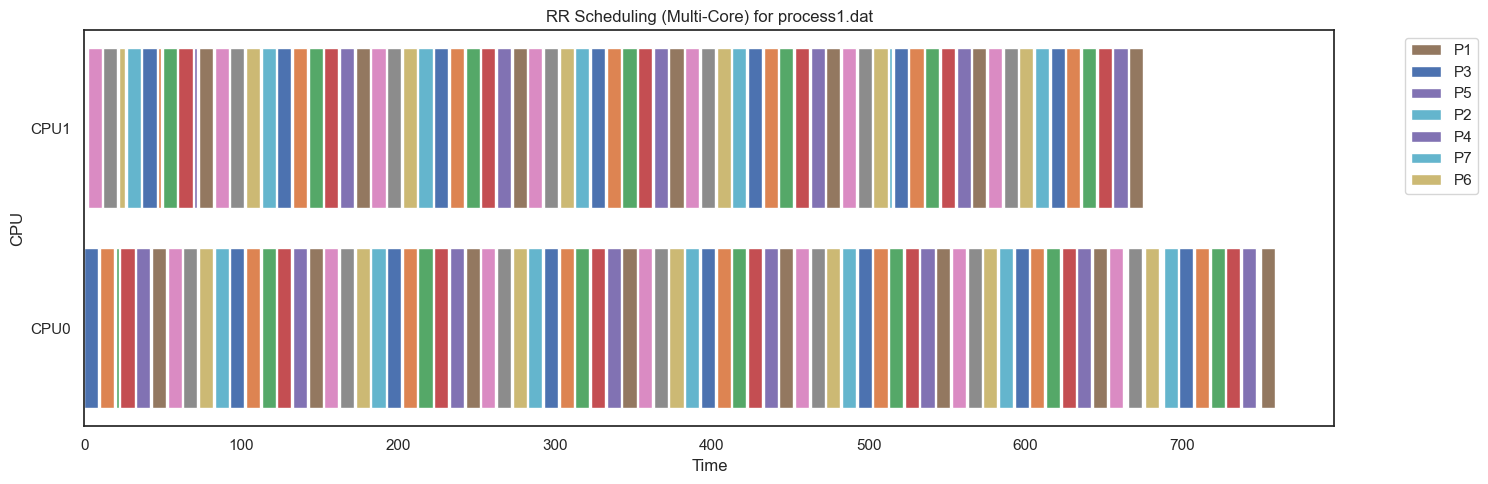

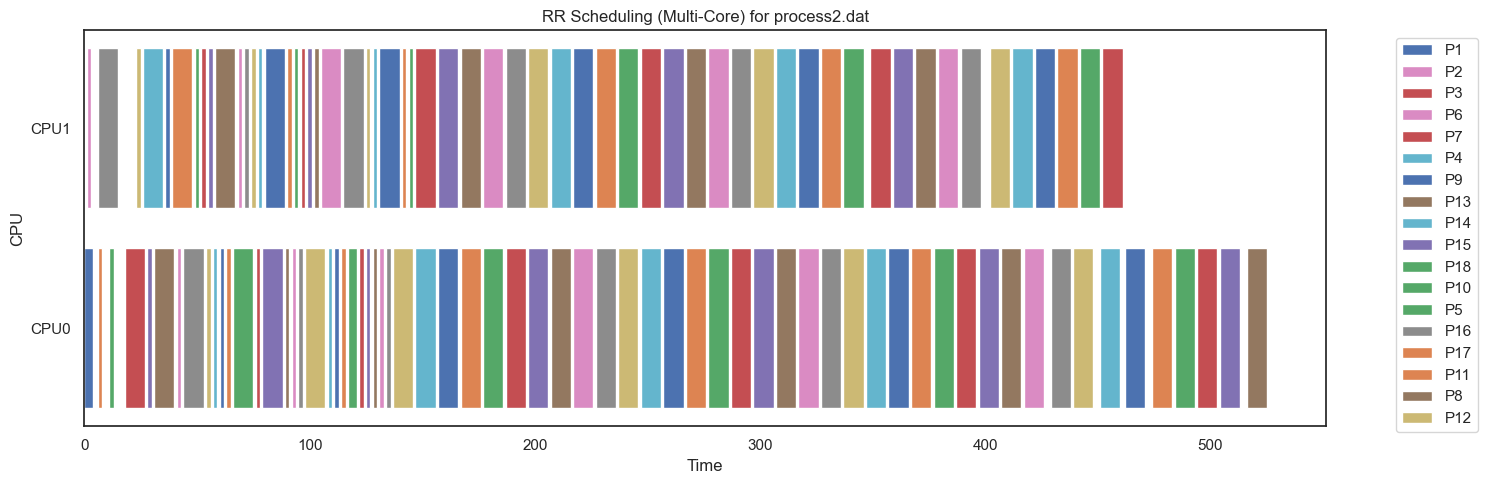

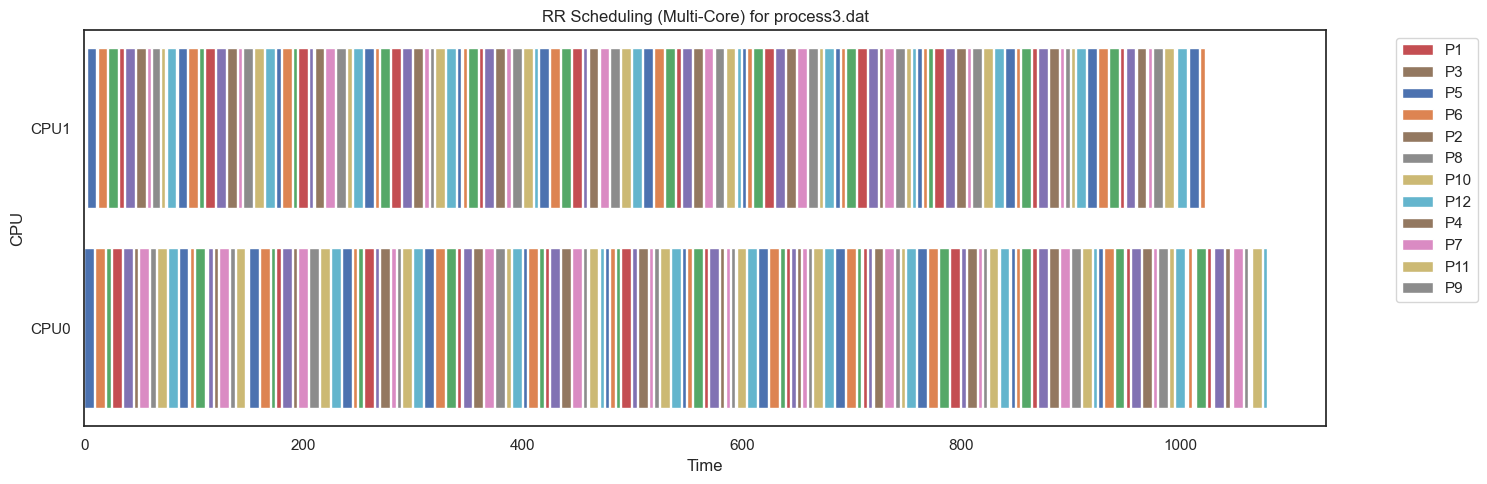

In [47]:
import matplotlib.pyplot as plt

alg0 = ["FIFO", "NPSJF","PSJF", "RR"]

for alg in alg0:
    for n in range(1, 4):
        rows = []
        n = str(n)
        with open("ScheduleMC(" + alg + ")" + n + ".txt") as f:
            current_cpu = None
            for line in f:
                parts = line.strip().split()
                
                # If line starts with CPUx (like CPU0 or CPU1), update current CPU
                if parts[0].startswith("CPU"):
                    current_cpu = parts[0]
                    continue
                
                # Otherwise it's a process line
                if len(parts) == 3:
                    proc_slice, start, end = parts
                    proc, slice_num = proc_slice.split(",")
                    rows.append((current_cpu, proc, int(slice_num), int(start), int(end)))
        
        # Plot Gantt Chart (multi-core timeline)
        fig, ax = plt.subplots(figsize=(15, 5))
        
        for cpu, proc, slice_num, start, end in rows:
            ax.barh(cpu, end - start, left=start, label=proc)
        
        ax.set_xlabel("Time")
        ax.set_ylabel("CPU")
        ax.set_title(alg + " Scheduling (Multi-Core) for process" + n + ".dat")
        
        # Avoid duplicate legend entries
        handles, labels = ax.get_legend_handles_labels()
        unique = dict(zip(labels, handles))
        ax.legend(unique.values(), unique.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.savefig(f"Gantt_{alg}_2process{n}.png", dpi=300, bbox_inches='tight')
        plt.tight_layout()
        plt.show()


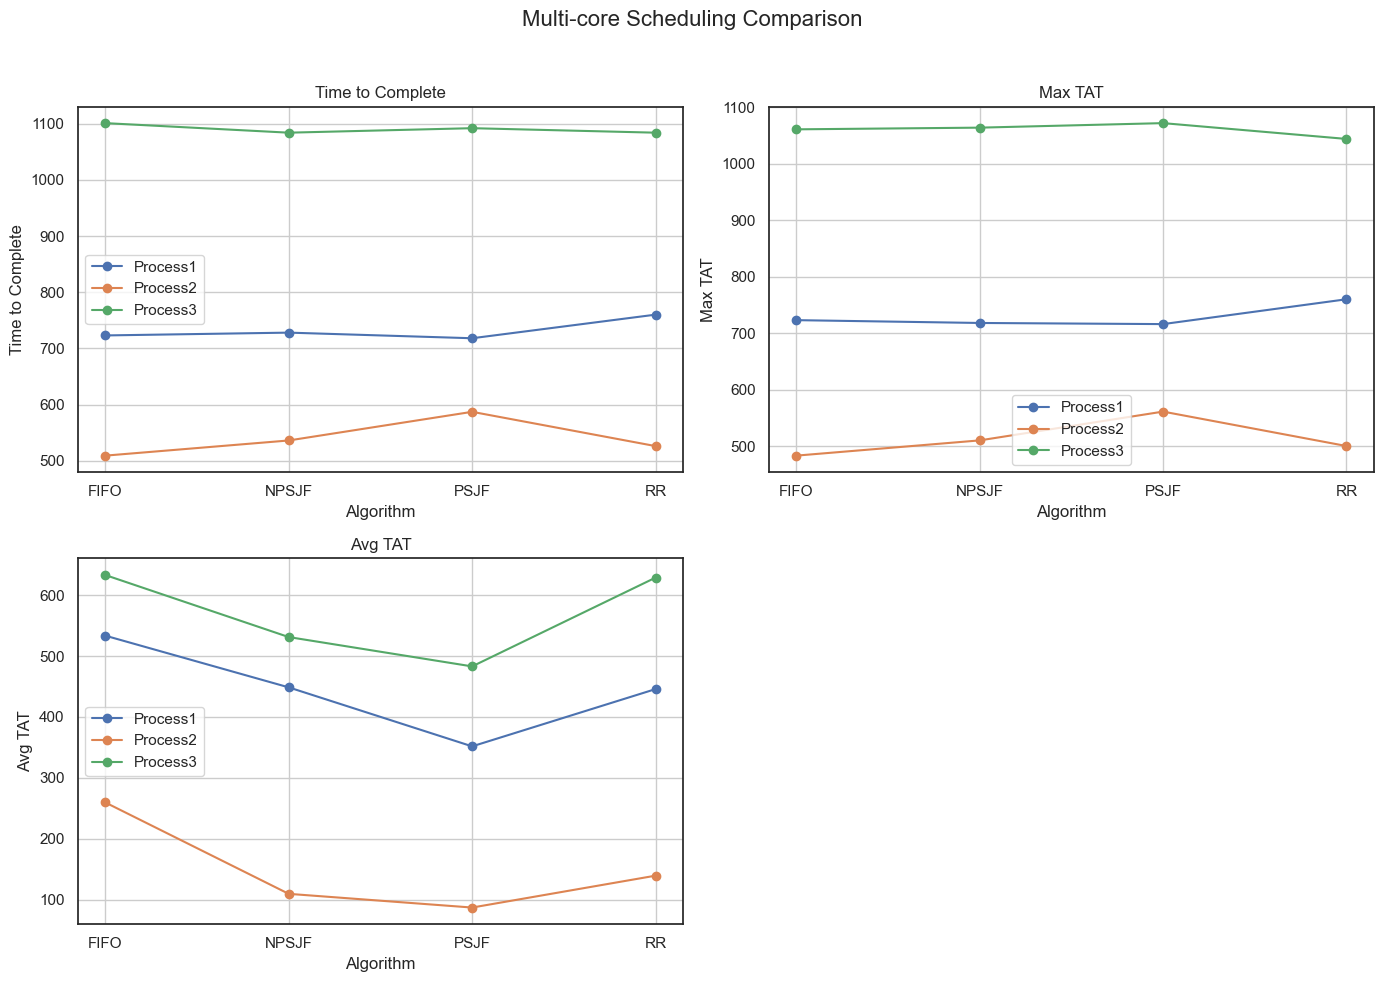

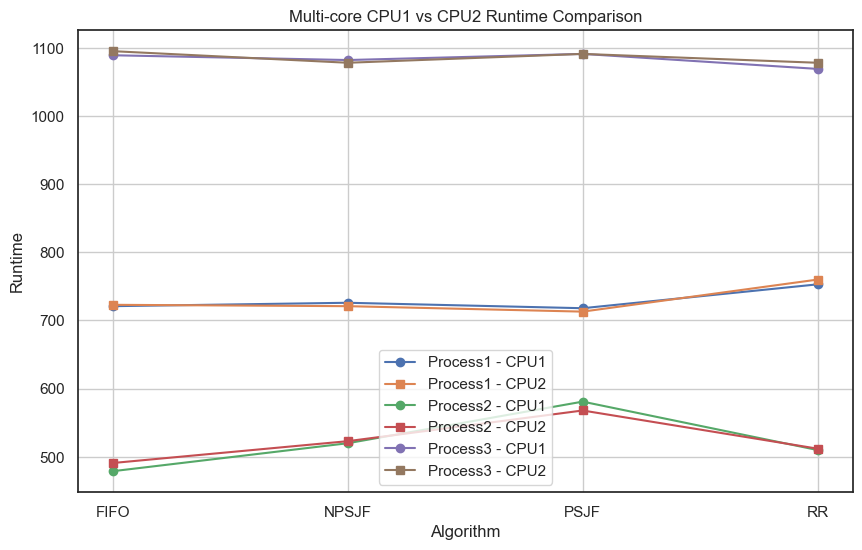

In [42]:
import matplotlib.pyplot as plt

# Algorithms
alg0 = ["FIFO", "NPSJF", "PSJF", "RR"]


# ---------------- Multi-core Data ---------------- #
# (FIFO + NPSJF + RR; PSJF was not run in your logs)
process1_toc_mc = [723, 728,718, 760]
process1_max_tat_mc = [723, 718,716, 760]
process1_avg_tat_mc = [533.429, 448.571,351.71, 445.714]
process1_cpu1 = [721, 726,718, 753]  # Runtime CPU1
process1_cpu2 = [723, 721,713, 760]  # Runtime CPU2

process2_toc_mc = [509, 536,587, 526]
process2_max_tat_mc = [483, 510,561, 500]
process2_avg_tat_mc = [259.556, 109.556,87.05, 139.389]
process2_cpu1 = [479, 520,581, 510]
process2_cpu2 = [491, 523,568, 512]

process3_toc_mc = [1101, 1084,1092, 1084]
process3_max_tat_mc = [1061, 1064,1072, 1044]
process3_avg_tat_mc = [633, 531.167,483, 628.75]
process3_cpu1 = [1089, 1082,1091, 1069]
process3_cpu2 = [1095, 1078,1091, 1078]

multi_core_data = {
    "Process1": (process1_toc_mc, process1_max_tat_mc, process1_avg_tat_mc),
    "Process2": (process2_toc_mc, process2_max_tat_mc, process2_avg_tat_mc),
    "Process3": (process3_toc_mc, process3_max_tat_mc, process3_avg_tat_mc),
}

multi_core_runtime = {
    "Process1": (process1_cpu1, process1_cpu2),
    "Process2": (process2_cpu1, process2_cpu2),
    "Process3": (process3_cpu1, process3_cpu2),
}

alg_mc = ["FIFO", "NPSJF","PSJF", "RR"]

# ---------------- Plotting Functions ---------------- #
def plot_metrics(datasets, algorithms, metrics, title, figsize=(14,10)):
    plt.figure(figsize=figsize)

    for i, metric in enumerate(metrics):
        plt.subplot(2, 2, i+1)
        for pname, pdata in datasets.items():
            plt.plot(algorithms, pdata[i], marker='o', label=pname)
        plt.title(metric)
        plt.xlabel("Algorithm")
        plt.ylabel(metric)
        plt.legend()
        plt.grid(True)

    plt.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

def plot_cpu_runtimes(runtime_data, algorithms, title):
    plt.figure(figsize=(10,6))
    for pname, pdata in runtime_data.items():
        cpu1, cpu2 = pdata
        plt.plot(algorithms, cpu1, marker='o', label=f"{pname} - CPU1")
        plt.plot(algorithms, cpu2, marker='s', label=f"{pname} - CPU2")
    plt.title(title)
    plt.xlabel("Algorithm")
    plt.ylabel("Runtime")
    plt.legend()
    plt.grid(True)
    plt.show()



# ---------------- Plot Multi-core ---------------- #
metrics_multi = ["Time to Complete", "Max TAT", "Avg TAT"]
plot_metrics(multi_core_data, alg_mc, metrics_multi, "Multi-core Scheduling Comparison")

# ---------------- Plot CPU1 vs CPU2 runtimes ---------------- #
plot_cpu_runtimes(multi_core_runtime, alg_mc, "Multi-core CPU1 vs CPU2 Runtime Comparison")


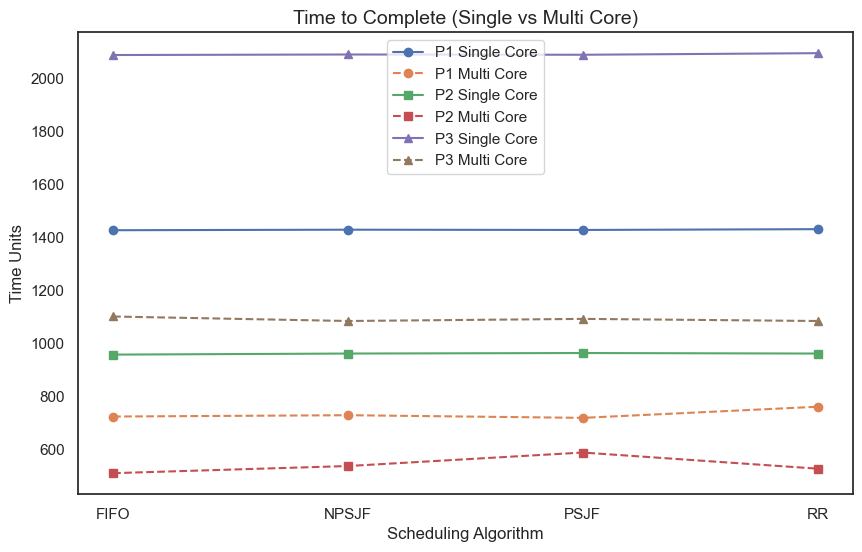

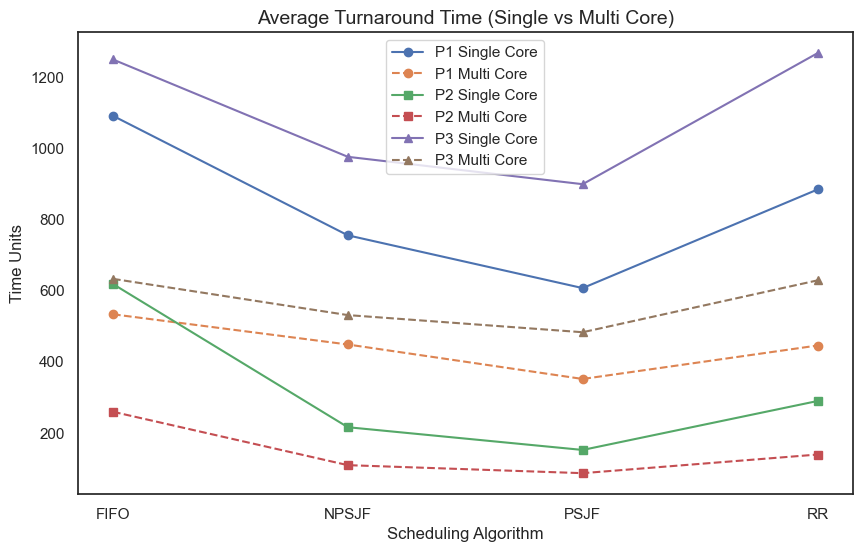

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Use seaborn style
sns.set(style="white")

# Algorithms
algorithms = ["FIFO", "NPSJF", "PSJF", "RR"]

# --- Single Core ---
process1_toc = [1427, 1429, 1428, 1431]
process1_avg_tat = [1091, 755.286, 607, 884]

process2_toc = [957, 961, 963, 961]
process2_avg_tat = [618.444, 216.167, 152.278, 289.778]

process3_toc = [2089, 2091, 2090, 2096]
process3_avg_tat = [1249.25, 975.833, 898.917, 1267]

# --- Multi Core ---
process1_toc_mc = [723, 728,718, 760]
process1_avg_tat_mc = [533.429, 448.571,351.7, 445.714]

process2_toc_mc = [509, 536, 587, 526]
process2_avg_tat_mc = [259.556, 109.556, 87.05, 139.389]

process3_toc_mc = [1101, 1084, 1092, 1084]
process3_avg_tat_mc = [633, 531.167, 483, 628.75]

# --- Plot 1: Time to Complete ---
plt.figure(figsize=(10, 6))

plt.plot(algorithms, process1_toc, marker='o', label="P1 Single Core")
plt.plot(algorithms, process1_toc_mc, marker='o', linestyle='--', label="P1 Multi Core")

plt.plot(algorithms, process2_toc, marker='s', label="P2 Single Core")
plt.plot(algorithms, process2_toc_mc, marker='s', linestyle='--', label="P2 Multi Core")

plt.plot(algorithms, process3_toc, marker='^', label="P3 Single Core")
plt.plot(algorithms, process3_toc_mc, marker='^', linestyle='--', label="P3 Multi Core")

plt.title("Time to Complete (Single vs Multi Core)", fontsize=14)
plt.xlabel("Scheduling Algorithm")
plt.ylabel("Time Units")
plt.legend()
plt.savefig(f"toc.png", dpi=300, bbox_inches='tight')
plt.show()

# --- Plot 2: Average TAT ---
plt.figure(figsize=(10, 6))

plt.plot(algorithms, process1_avg_tat, marker='o', label="P1 Single Core")
plt.plot(algorithms, process1_avg_tat_mc, marker='o', linestyle='--', label="P1 Multi Core")

plt.plot(algorithms, process2_avg_tat, marker='s', label="P2 Single Core")
plt.plot(algorithms, process2_avg_tat_mc, marker='s', linestyle='--', label="P2 Multi Core")

plt.plot(algorithms, process3_avg_tat, marker='^', label="P3 Single Core")
plt.plot(algorithms, process3_avg_tat_mc, marker='^', linestyle='--', label="P3 Multi Core")

plt.title("Average Turnaround Time (Single vs Multi Core)", fontsize=14)
plt.xlabel("Scheduling Algorithm")
plt.ylabel("Time Units")
plt.legend()
plt.savefig(f"avg.png", dpi=300, bbox_inches='tight')
plt.show()
